# The Jupyter Notebook that Analyses R  
**Damian**

---

This notebook is structured as follows:

In the first cell below, an overview is given of the research into the observational biases that affect luminosity ($L$) and effective temperature ($T_{\mathrm{eff}}$), and therefore also influence the derived stellar radius ($R$) and all associated ratios. In the same cell, following the explanation of these biases and their effects, methods for correcting these biases are discussed.

In the next cell (not yet created), all required imports will be included.

In the cell after that (also not yet created), the necessary data will be loaded.

Finally, in the following cell (also not yet created), the data analysis and bias correction will be performed.

# Information about the biases affecting R.

This section summarizes the main observational biases affecting binary star systems, and how these biases influence the measured luminosity ($L$), effective temperature ($T_{\mathrm{eff}}$), and derived stellar radius ($R$), as well as their ratios.

---

## 1. Luminosity (Brightness) Bias

**Explanation**  
Brighter systems are easier to detect than faint systems, especially at larger distances. As a result, intrinsically luminous stars and systems are overrepresented in the dataset, while faint systems fall below the detection threshold.

**Effect on $L$, $T_{\mathrm{eff}}$, and $R$**  
This bias leads to an overestimation of the average luminosity $L$. Since hotter stars are generally more luminous, the average effective temperature $T_{\mathrm{eff}}$ is also biased toward higher values. Because the stellar radius depends on both parameters,
$$
R \propto \frac{\sqrt{L}}{T_{\mathrm{eff}}^2},
$$
an increase in $L$ leads to larger inferred radii, while an increase in $T_{\mathrm{eff}}$ partially counteracts this effect.

**Effect on Ratios**  
Systems with large luminosity differences are harder to detect, so luminosity ratios tend to be biased toward values closer to 1. Extreme ratios are underrepresented.

---

## 2. Temperature Bias

**Explanation**  
Hotter stars are brighter and have clearer spectral features, making them easier to detect and analyze. Cooler stars are fainter and can be more difficult to identify, especially in binary systems.

**Effect on $L$, $T_{\mathrm{eff}}$, and $R$**  
This bias results in an overrepresentation of stars with high $T_{\mathrm{eff}}$. Since temperature and luminosity are correlated, $L$ is also biased toward higher values. Because $R \propto T^{-2}$, an overestimated temperature can lead to underestimated stellar radii.

**Effect on Ratios**  
Cooler secondary stars are more likely to be missed or poorly measured, causing temperature ratios to cluster closer to 1 and reducing the number of systems with large temperature contrasts.

---

## 3. Mass-Ratio Bias

**Explanation**  
Binary systems with similar components (mass ratio $q \approx 1$) are easier to detect than systems where one star is much fainter than the other. In high-contrast systems, the secondary component may be lost in the light of the primary.

**Effect on $L$, $T_{\mathrm{eff}}$, and $R$**  
Because similar-component systems are overrepresented, the measured values of $L$ and $T_{\mathrm{eff}}$ for the two stars tend to be more alike. This also leads to less variation in the derived stellar radii.

**Effect on Ratios**  
Ratios such as $L_1/L_2$, $T_1/T_2$, and $R_1/R_2$ are biased toward unity, while extreme values are underrepresented.

---

## 4. Inclination Bias

**Explanation**  
The detection of certain binary systems depends on their orbital inclination. For example, eclipsing binaries are only observable when the system is viewed nearly edge-on.

**Effect on $L$, $T_{\mathrm{eff}}$, and $R$**  
This bias selects systems that are easier to characterize, leading to more reliable measurements of $L$, $T_{\mathrm{eff}}$, and $R$. However, these systems are not necessarily representative of the full binary population.

**Effect on Ratios**  
Ratios in these systems are often more accurately determined, but the sample is biased toward systems that are favorable for observation, which may indirectly affect the observed distribution.

---

## 5. Period Bias

**Explanation**  
Short-period binaries are easier to detect because they show more frequent eclipses and larger radial velocity variations. Long-period systems are less likely to be identified as binaries.

**Effect on $L$, $T_{\mathrm{eff}}$, and $R$**  
Short-period systems often experience interactions such as tidal locking or mass transfer, which can make the component stars more similar in temperature and luminosity. This can influence the measured distributions of $L$ and $T_{\mathrm{eff}}$.

**Effect on Ratios**  
Because the components tend to be more similar, the ratios $L_1/L_2$, $T_1/T_2$, and $R_1/R_2$ are more likely to be close to 1.

---

## 6. Blending / Unresolved Bias

**Explanation**  
In some cases, two stars cannot be resolved individually and appear as a single object. This is especially common when one component is much fainter than the other.

**Effect on $L$, $T_{\mathrm{eff}}$, and $R$**  
The measured flux is then a combination of both stars, leading to an overestimation of $L$ and a distorted estimate of $T_{\mathrm{eff}}$. This propagates into errors in the derived stellar radius $R$.

**Effect on Ratios**  
Systems with large differences between components may be misidentified as single stars and therefore excluded from the dataset. As a result, extreme ratios are underrepresented, and observed ratios are biased toward values near 1.

In [ ]:
# Imports here:

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

Totaal aantal rows: 107881
Rows met bekende L: 3368

===== STATISTIEKEN VAN L =====
count      3368.000000
mean       1484.134571
std       14787.988692
min          -0.410000
25%           0.900000
50%           3.856000
75%          30.205000
max      271010.140000
Name: L, dtype: float64

===== KLEINSTE L-WAARDEN =====
106066   -0.41
106065   -0.41
106067   -0.41
106075   -0.41
106077   -0.41
106078   -0.41
106076   -0.41
106079   -0.41
43682    -0.38
43681    -0.38
68028    -0.32
68027    -0.32
12760    -0.31
12762    -0.31
31704    -0.31
31703    -0.31
59785    -0.26
52384    -0.17
52379    -0.17
80393    -0.13
Name: L, dtype: float64

===== GROOTSTE L-WAARDEN =====
103853    271010.14
103852    271010.14
103861    254114.89
103845    254114.89
103867    254114.89
103868    254114.89
103847    254114.89
103846    254114.89
103866    254114.89
103863    254114.89
100415     80646.09
100416     80646.09
50201      77893.22
50200      77893.22
99395      69692.11
80052      64749.06


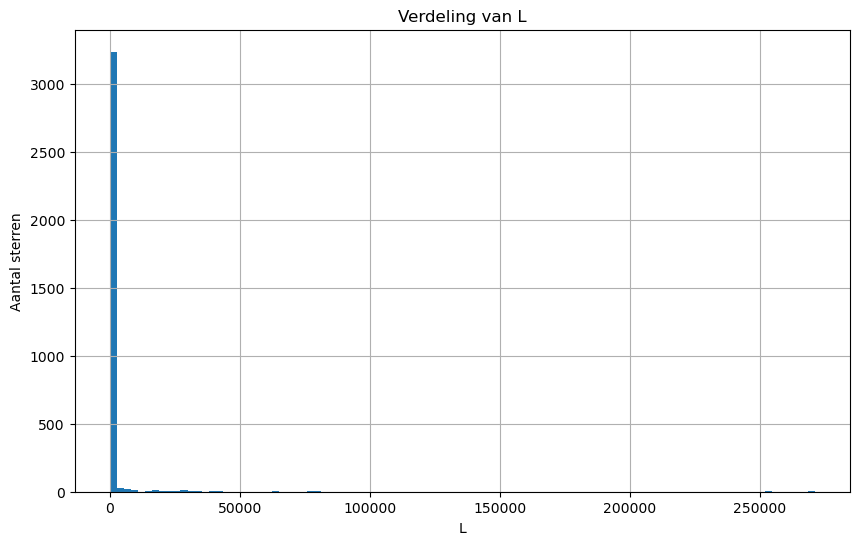


===== PER CATALOGUE STATISTIEK VAN L =====
                   count         mean           std    min      25%      50%  \
catalogue                                                                      
II/150A           2275.0  2196.627029  17950.782399  0.010  2.82000  15.2000   
J/MNRAS/491/5489   462.0     1.735102      1.435967 -0.410  0.72300   1.3000   
Svechnikov84       400.0     0.706829      0.205865  0.043  0.57000   0.7370   
Svechnikov99       181.0     0.672525      0.151934  0.488  0.54500   0.6200   
V/118               50.0     0.653380      0.136209  0.500  0.53725   0.6195   

                       75%         max  
catalogue                               
II/150A           58.27000  271010.140  
J/MNRAS/491/5489   2.29000       5.460  
Svechnikov84       0.87675       1.000  
Svechnikov99       0.78000       0.999  
V/118              0.74150       0.998  

===== EXTRA SAMENVATTING =====
                         mean   median    min         max           std  cou

In [11]:
# Inlezen en eerste processing van data


# ============================================================
# 1. Data inlezen
# ============================================================

df = pd.read_csv(r'DATA/RAW/L_SP.csv')

print("Totaal aantal rows:", len(df))

# ============================================================
# 2. Alleen rows behouden met bekende luminositeit (L)
# ============================================================

df["L"] = df["L"].replace("", pd.NA)
df = df.dropna(subset=["L"])

# Zorg dat L numeriek is
df["L"] = pd.to_numeric(df["L"], errors="coerce")

# eventuele niet-numerieke waarden verwijderen
df = df.dropna(subset=["L"])

print("Rows met bekende L:", len(df))

# ============================================================
# CHECK VAN DE L-WAARDEN
# ============================================================

print("\n===== STATISTIEKEN VAN L =====")

print(df["L"].describe())

# ============================================================
# Kleinste en grootste waarden bekijken
# ============================================================

print("\n===== KLEINSTE L-WAARDEN =====")
print(
    df["L"]
    .sort_values()
    .head(20)
)

print("\n===== GROOTSTE L-WAARDEN =====")
print(
    df["L"]
    .sort_values(ascending=False)
    .head(20)
)

# ============================================================
# Unieke waarden bekijken
# ============================================================

print("\n===== EERSTE 50 UNIEKE L-WAARDEN =====")

unique_L = np.sort(df["L"].unique())

print(unique_L[:50])

# ============================================================
# Histogram maken
# ============================================================

plt.figure(figsize=(10, 6))

plt.hist(df["L"], bins=100)

plt.xlabel("L")
plt.ylabel("Aantal sterren")

plt.title("Verdeling van L")

plt.grid(True)

plt.show()

# ============================================================
# PER CATALOGUE L-VERDELING CHECKEN
# ============================================================

print("\n===== PER CATALOGUE STATISTIEK VAN L =====")

catalogue_stats = df.groupby("catalogue")["L"].describe()

print(catalogue_stats)

# ============================================================
# Extra: per catalogue median en range (handig voor schaal-detectie)
# ============================================================

print("\n===== EXTRA SAMENVATTING =====")

summary = df.groupby("catalogue")["L"].agg(
    mean="mean",
    median="median",
    min="min",
    max="max",
    std="std",
    count="count"
)

print(summary.sort_values(by="count", ascending=False))

# ============================================================
# 3. Overzicht van databases/catalogi
# ============================================================

print("\n===== DATABASE OVERZICHT =====")

catalogue_counts = (
    df["catalogue"]
    .value_counts()
    .reset_index()
)

catalogue_counts.columns = ["catalogue", "n_rows"]

print(catalogue_counts)

# ============================================================
# 4. system_id en component uit bsdb halen
# ============================================================

df[["system_id", "component"]] = (
    df["bsdb"]
    .str.split(":", expand=True)
)

# ============================================================
# 5. Structuur van systemen bepalen
# ============================================================

system_structure = (
    df.groupby("system_id")["component"]
    .nunique()
    .reset_index(name="n_components")
)

# ============================================================
# 6. Alleen dubbelstersystemen behouden
# ============================================================

binary_systems = system_structure[
    system_structure["n_components"] == 2
]

print("Aantal dubbelstersystemen:", len(binary_systems))

# ============================================================
# 7. Alle rows van dubbelstersystemen behouden
# ============================================================

binary_df = df[
    df["system_id"].isin(binary_systems["system_id"])
].copy()

# ============================================================
# 8. Catalogue priorities
# ============================================================

catalog_priority = {
    "J/MNRAS/491/5489": 5,
    "V/118": 4,
    "Svechnikov99": 3,
    "Svechnikov84": 2,
    "II/150A": 1
}

# gewicht toevoegen
binary_df["weight"] = (
    binary_df["catalogue"]
    .map(catalog_priority)
    .fillna(1)
)

# ============================================================
# 9. Weighted average functie
# ============================================================

def weighted_mean(values, weights):
    return np.average(values, weights=weights)

def weighted_std(values, weights):
    mean = weighted_mean(values, weights)
    variance = np.average((values - mean) ** 2, weights=weights)
    return np.sqrt(variance)

# ============================================================
# 10. Resolven van duplicate luminosities
# ============================================================

resolved_stars = []

grouped = binary_df.groupby(["system_id", "component"])

for (system_id, component), group in grouped:

    working = group.copy()

    while True:

        values = working["L"].values
        weights = working["weight"].values

        mean = weighted_mean(values, weights)
        std = weighted_std(values, weights)

        ratio = std / mean if mean != 0 else np.inf

        # ====================================================
        # Situatie OK
        # ====================================================

        if ratio <= 0.1:

            resolved_stars.append({
                "system_id": system_id,
                "component": component,
                "final_L": mean,
                "std": std,
                "std_ratio": ratio,
                "n_measurements": len(working),
                "status": "accepted"
            })

            break

        # ====================================================
        # Nog maar 2 entries over
        # ====================================================

        if len(working) == 2:

            # hoogste gewicht kiezen
            best_idx = working["weight"].idxmax()

            best_row = working.loc[best_idx]

            resolved_stars.append({
                "system_id": system_id,
                "component": component,
                "final_L": best_row["L"],
                "std": std,
                "std_ratio": ratio,
                "n_measurements": len(working),
                "status": "fallback_best_catalogue"
            })

            break

        # ====================================================
        # 3 of meer entries
        # ====================================================

        else:

            # slechtste catalogue verwijderen
            min_weight = working["weight"].min()

            low_priority_rows = working[
                working["weight"] == min_weight
            ]

            # ------------------------------------------------
            # Als meerdere dezelfde slechte catalogue hebben:
            # verwijder grootste outlier
            # ------------------------------------------------

            if len(low_priority_rows) > 1:

                distances = np.abs(
                    low_priority_rows["L"] - mean
                )

                remove_idx = distances.idxmax()

            else:

                remove_idx = low_priority_rows.index[0]

            # row verwijderen
            working = working.drop(remove_idx)

# ============================================================
# 11. Resultaten dataframe
# ============================================================

resolved_df = pd.DataFrame(resolved_stars)

# ============================================================
# 12. Resultaten printen
# ============================================================

print("\n===== RESULTATEN =====")

print("Aantal unieke sterren:")
print(len(resolved_df))

print("\nStatus verdeling:")
print(
    resolved_df["status"]
    .value_counts()
)

print("\nGemiddelde std/mean ratio:")
print(
    resolved_df["std_ratio"]
    .mean()
)

# ============================================================
# 13. Voorbeeld output
# ============================================================

print("\nVoorbeeld resolved luminosities:")

print(
    resolved_df.head(20)
)

In [ ]:
# Analysis of said data happens over here: